In [113]:
import os
import json
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import calendar
import pandas as pd

from astral import sun
from astral.location import Observer

from scipy.stats import contingency

#### Step 0. Fetching data with requests

#### Step 1. Data Selection & Field Flattening

In [114]:
# Loading Earthquake JSON files 
dir = "/Users/paus/Projects/da_capstone/data/"
dir = Path(dir)

json_data_eq = {}
# Explicitly load the file into the dictionary using a static string key
for file in dir.glob("usgs_sample_raw.json"):
    with open(file, "r") as f:
        json_data_eq[file.stem] = json.load(f)

#### Step 2. Extracting Data from JSON

In [115]:
# Multiple File Loop through the JSON file and extract the variables of interest

usgs_eq_data = {} #storage dictionary

for name, data in json_data_eq.items():

    usgs_eq_rows = []

    for event in data["features"]:
        prop = event["properties"]
        coords = event["geometry"]["coordinates"]

        usgs_eq_row = {
            "id": event.get("id"),
            "mag": prop.get("mag"),
            "place": prop.get("place"),
            "time": prop.get("time"),
            "updated": prop.get("updated"),
            "magType": prop.get("magType"),
            "duration": prop.get("dmin"),
            "longitude": coords[0],
            "latitude": coords[1],
            "depth_km": coords[2]
        }

        usgs_eq_rows.append(usgs_eq_row)

    usgs_eq_data[name] = usgs_eq_rows

#### Step 3. Convert/Upload into Dataframes

In [116]:
usgs_eq_df = pd.DataFrame(usgs_eq_rows)

##### Basic exploratory steps

In [117]:
print(usgs_eq_df.shape)        # number of events × number of columns

(50, 10)


In [118]:
print(usgs_eq_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         50 non-null     object 
 1   mag        50 non-null     float64
 2   place      50 non-null     object 
 3   time       50 non-null     int64  
 4   updated    50 non-null     int64  
 5   magType    50 non-null     object 
 6   duration   36 non-null     float64
 7   longitude  50 non-null     float64
 8   latitude   50 non-null     float64
 9   depth_km   50 non-null     float64
dtypes: float64(5), int64(2), object(3)
memory usage: 4.0+ KB
None


#### Step 4. Tidying & Cleaning dataframes

In [119]:
# Standarize columns
usgs_eq_df.columns = (
    usgs_eq_df.columns
        .str.strip()
        # Split lower→upper (camelCase)
        .str.replace(r'(?<=[a-z0-9])(?=[A-Z])', '_', regex=True)
        # Split acronym→word (KPMin, CMEID → kp_min, cme_id)
        .str.replace(r'(?<=[A-Z])(?=[A-Z][a-z])', '_', regex=True)
        .str.lower()
)

In [120]:
# Time and updated variables are in Unix time (milliseconds)
# Convert from milliseconds to datetime (UTC)
usgs_eq_df["start_time"] = pd.to_datetime(usgs_eq_df["time"], unit="ms", utc=True)
usgs_eq_df["updated_utc"] = pd.to_datetime(usgs_eq_df["updated"], unit="ms", utc=True)

print(usgs_eq_df[["time", "start_time"]].head())

            time                       start_time
0  1391339556390 2014-02-02 11:12:36.390000+00:00
1  1396407374240 2014-04-02 02:56:14.240000+00:00
2  1399413039500 2014-05-06 21:50:39.500000+00:00
3  1397177105810 2014-04-11 00:45:05.810000+00:00
4  1397010839680 2014-04-09 02:33:59.680000+00:00


In [121]:
# Extract State & location names
usgs_eq_df["state"] = usgs_eq_df["place"].str.split(",").str[-1].str.strip()
usgs_eq_df["state"].value_counts().head()

state
Alaska         10
Indonesia       4
Chile           3
Philippines     2
Mexico          2
Name: count, dtype: int64

In [122]:
usgs_eq_df["eq_location"] = (
    usgs_eq_df["place"]
    .str.split(" of ")
    .str[-1]
    .str.split(",")
    .str[0]
    .str.strip()
)

In [123]:
usgs_eq_df["mag_type"] = usgs_eq_df["mag_type"].astype("category")
usgs_eq_df["eq_location"] = usgs_eq_df["eq_location"].astype("category")
usgs_eq_df["state"] = usgs_eq_df["state"].astype("category")

#### Step 5. Feature Engeneering

##### - ⩇⩇:⩇⩇ UCT Timestamps

In [124]:
# Make sure start_time is datetime
usgs_eq_df["start_time"] = pd.to_datetime(usgs_eq_df["start_time"], errors="coerce")

In [125]:
# min, max, median
print(usgs_eq_df["start_time"].min())
print(usgs_eq_df["start_time"].max())
print(usgs_eq_df["start_time"].median())

# Extract the time features
usgs_eq_df["year"] = usgs_eq_df["start_time"].dt.year
usgs_eq_df["month"] = usgs_eq_df["start_time"].dt.month
usgs_eq_df["dayofweek"] = usgs_eq_df["start_time"].dt.dayofweek
usgs_eq_df["hour"] = usgs_eq_df["start_time"].dt.hour

# check type
usgs_eq_df.dtypes["start_time"]
# returns: datetime64[ns]

2014-01-08 08:04:18.791000+00:00
2014-06-24 02:04:13+00:00
2014-04-05 14:45:06.960000+00:00


datetime64[ns, UTC]

In [126]:
# Cleaning the dates considering that date layouts may be mixed
usgs_eq_df["start_time"] = pd.to_datetime(
    usgs_eq_df["start_time"],
    format="mixed"
).dt.tz_localize(None)

# Monthly buckets
usgs_eq_df["year_month"] = usgs_eq_df["start_time"].dt.to_period("M")

# Creating variable of earthquake counts per month
monthly_counts = usgs_eq_df.groupby("year_month").size()

# timeline graph-ready variable into sequential timestamps (start of the month)
monthly_counts.index = monthly_counts.index.to_timestamp()

# Checking records
usgs_eq_df["start_time"].isna().sum()

np.int64(0)

In [127]:
# Prerequisite: Import calendar module and extract helper datetime properties
# Create the missing 'dayofweek' and 'hour' attributes from your timestamps
usgs_eq_df["dayofweek"] = usgs_eq_df["start_time"].dt.dayofweek
usgs_eq_df["hour"] = usgs_eq_df["start_time"].dt.hour

# Weekday Extraction (0 = Monday, 6 = Sunday)
# calendar.day_abbr maps integers safely to ['Mon', 'Tue', 'Wed'...]
usgs_eq_df["day_name"] = usgs_eq_df["dayofweek"].apply(
    lambda x: calendar.day_abbr[x] if pd.notna(x) else "Unknown"
)

# Standard Time Part Extractions
usgs_eq_df["month_name"] = usgs_eq_df["start_time"].dt.month_name()
usgs_eq_df["week_of_year"] = usgs_eq_df["start_time"].dt.isocalendar().week.astype(int)
usgs_eq_df["quarter"] = usgs_eq_df["start_time"].dt.quarter
usgs_eq_df["day_of_month"] = usgs_eq_df["start_time"].dt.day
usgs_eq_df["day_of_year"] = usgs_eq_df["start_time"].dt.dayofyear

# Weekend Flag (In Pandas .dayofweek, 5 is Saturday and 6 is Sunday)
usgs_eq_df["is_weekend"] = usgs_eq_df["dayofweek"].isin([5, 6])

# Time-of-Day Categorization Function
def get_time_of_day(hour):
    if pd.isna(hour):
        return "Unknown"
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

# Apply custom categorization function safely
usgs_eq_df["time_of_day"] = usgs_eq_df["hour"].apply(get_time_of_day)

# Establish Strict Chronological Ordering for Months to ensure beautiful graphs
usgs_eq_df["month_name"] = pd.Categorical(
    usgs_eq_df["month_name"],
    categories=list(calendar.month_name)[1:],  # Drops empty index 0, keeps ['January'...'December']
    ordered=True
)

usgs_eq_df['month_name'].value_counts(sort=False)

day_order = list(calendar.day_abbr)  # ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

usgs_eq_df["day_name"] = pd.Categorical(
    usgs_eq_df["day_name"],
    categories=day_order,
    ordered=True
)

# 🔎 Verify our newly engineered categorical attributes
print("📊 Engineered Time Features:")
print(usgs_eq_df[["start_time", "day_name", "time_of_day", "is_weekend", "month_name", "day_name"]].head(3))


📊 Engineered Time Features:
               start_time day_name time_of_day  is_weekend month_name day_name
0 2014-02-02 11:12:36.390      Sun     Morning        True   February      Sun
1 2014-04-02 02:56:14.240      Wed       Night       False      April      Wed
2 2014-05-06 21:50:39.500      Tue     Evening       False        May      Tue


##### - 🌤️ Local Solar Time Estimation

_Did the earthquake happen during the day or at night at the actual location of the epicenter?_

```astral``` enables a more accurate than the simple longitude math because it accounts for the curvature of the earth and the time of year.

In [128]:
#import pandas as pd

# ==============================================================================
# 1. CLEAN METHOD A: APPROXIMATE LOCAL SOLAR TIME (LST)
# ==============================================================================
# Ensure start_time is treated as a clean timezone-naive UTC timestamp first
usgs_eq_df["start_time_naive"] = pd.to_datetime(usgs_eq_df["start_time"]).dt.tz_localize(None)

# Every 15 degrees of longitude equals a 1-hour shift from the prime meridian
usgs_eq_df["solar_offset_hours"] = usgs_eq_df["longitude"] / 15.0
usgs_eq_df["solar_offset"] = pd.to_timedelta(usgs_eq_df["solar_offset_hours"], unit="h")

# Calculate Local Solar Time
usgs_eq_df["local_solar_time"] = usgs_eq_df["start_time_naive"] + usgs_eq_df["solar_offset"]

# Convert to a decimal hour format (e.g., 14:30 becomes 14.5)
usgs_eq_df["lst_hour"] = usgs_eq_df["local_solar_time"].dt.hour + (usgs_eq_df["local_solar_time"].dt.minute / 60.0)

# Estimate daylight (Basic rule: Sun is up between 6 AM and 6 PM)
usgs_eq_df["is_daylight_approx"] = usgs_eq_df["lst_hour"].between(6.0, 18.0)

In [129]:
#from astral import sun
#from astral.location import Observer

# ==============================================================================
# 2. CLEAN METHOD B: EXACT SCIENTIFIC SOLAR ELEVATION (ASTRAL)
# ==============================================================================
def calculate_true_daylight(row):
    """Calculates if the sun was physically above the horizon at the epicenter."""
    # Check for empty coordinates to avoid crashes
    if pd.isna(row["latitude"]) or pd.isna(row["longitude"]) or pd.isna(row["start_time_naive"]):
        return False
        
    try:
        # Define the location profile for the earthquake epicenter
        observer = Observer(latitude=float(row["latitude"]), longitude=float(row["longitude"]))
        
        # Convert timestamp to a standard python datetime object
        dt = row["start_time_naive"].to_pydatetime()
        
        # If solar elevation angle is greater than 0, it means it is daytime there!
        return sun.elevation(observer, dt) > 0
    except Exception:
        # Fallback security check in case of corrupted coordinates
        return False

# Safely apply the scientific calculation across your 50 points
usgs_eq_df["is_daylight_scientific"] = usgs_eq_df.apply(calculate_true_daylight, axis=1)


In [130]:
# ==============================================================================
# 3. VERIFICATION & OUTPUT LOG
# ==============================================================================
print("📊 Scientific Daylight Value Counts:")
print(usgs_eq_df["is_daylight_scientific"].value_counts())

print("\n🔎 Comparison Preview (Approximate vs Scientific):")
print(usgs_eq_df[["local_solar_time", "lst_hour", "is_daylight_approx", "is_daylight_scientific"]].head(3))

📊 Scientific Daylight Value Counts:
is_daylight_scientific
False    28
True     22
Name: count, dtype: int64

🔎 Comparison Preview (Approximate vs Scientific):
               local_solar_time   lst_hour  is_daylight_approx  \
0 2014-02-02 18:29:41.429999998  18.483333               False   
1 2014-04-01 22:13:02.696000002  22.216667               False   
2 2014-05-07 04:44:02.132000000   4.733333               False   

   is_daylight_scientific  
0                   False  
1                   False  
2                   False  


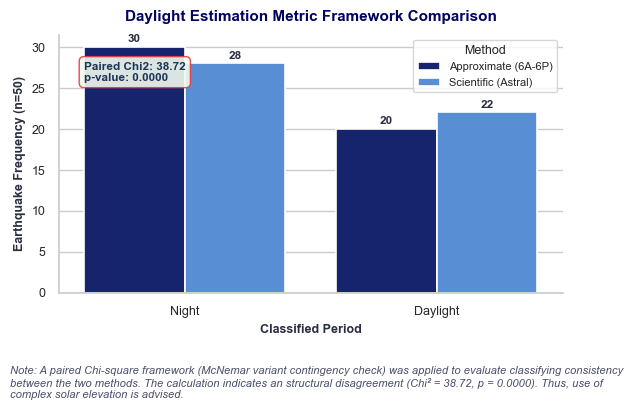

In [161]:
import calendar
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import contingency

# ==============================================================================
# 1. STATISTICAL EVALUATION & DYNAMIC TEXT LOGIC
# ==============================================================================
crosstab = pd.crosstab(
    usgs_eq_df["is_daylight_approx"], usgs_eq_df["is_daylight_scientific"]
)

try:
    obs = crosstab.values
    chi2, p_val, dof, expected = contingency.chi2_contingency(obs)

    # Define the variables needed for your inner plot text box
    stat_label = f"Paired Chi2: {chi2:.2f}\np-value: {p_val:.4f}"

    if p_val <= 0.05:
        finding_text = f"structural disagreement (Chi² = {chi2:.2f}, p = {p_val:.4f}). Thus, use of complex solar elevation is advised."
    else:
        finding_text = f"no statistically significant difference (Chi² = {chi2:.2f}, p = {p_val:.4f}). both methods classified daylight boundaries similarly for n=50 small sample size."

except Exception:
    chi2, p_val = 0.0, 1.0
    finding_text = "no variance or insufficient distribution profile variations to compute a valid cross-tabulation matrix."

# The precise scientific caption string
dynamic_caption = f"Note: A paired Chi-square framework (McNemar variant contingency check) was applied to evaluate classifying consistency between the two methods. The calculation indicates an {finding_text}"

# ==============================================================================
# 2. DATA PREPARATION (COMPACT DESIGN)
# ==============================================================================
approx_counts = (
    usgs_eq_df["is_daylight_approx"]
    .value_counts()
    .rename({True: "Daylight", False: "Night"})
)
sci_counts = (
    usgs_eq_df["is_daylight_scientific"]
    .value_counts()
    .rename({True: "Daylight", False: "Night"})
)

plot_data = (
    pd.DataFrame(
        {"Approximate (6A-6P)": approx_counts, "Scientific (Astral)": sci_counts}
    )
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "Period"})
)
plot_data_melted = plot_data.melt(
    id_vars="Period", var_name="Method", value_name="Count"
)

# ==============================================================================
# 3. DRAW COMPACT PLOT WITH INTEGRATED FIGURE CAPTION
# ==============================================================================
sns.set_theme(style="whitegrid")

# Expanded the canvas height slightly (from 3.5 to 4.3) to make room for the note at the bottom
fig, ax = plt.subplots(figsize=(6.5, 4.3))
custom_colors = ["#061B7C", "#438DE9"]

sns.barplot(
    data=plot_data_melted,
    x="Period",
    y="Count",
    hue="Method",
    palette=custom_colors,
    edgecolor="white",
    linewidth=1.2,
    ax=ax,
)

# Typography & Layout Tweak
ax.set_title(
    "Daylight Estimation Metric Framework Comparison",
    fontsize=11,
    fontweight="bold",
    color="#03045E",
    pad=10,
)
ax.set_xlabel("Classified Period", fontsize=9, fontweight="semibold", color="#2B2D42")
ax.set_ylabel(
    "Earthquake Frequency (n=50)", fontsize=9, fontweight="semibold", color="#2B2D42"
)
ax.tick_params(labelsize=9)
sns.despine()
ax.legend(title="Method", title_fontsize="9", fontsize="8", loc="upper right")

# Set bar data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=2,
        fontsize=8.5,
        fontweight="bold",
        color="#2B2D42",
    )

# INTEGRATE STATS HIGHLIGHT TEXT BOX
# Placed safely on the side to give an explicit insight into performance
ax.text(
    0.05,
    0.82,
    stat_label,
    transform=ax.transAxes,
    fontsize=8.5,
    fontweight="bold",
    color="#1D3557",
    bbox=dict(
        boxstyle="round,pad=0.4", facecolor="#F1FAEE", edgecolor="#E63946", alpha=0.9
    )
)
# ------------------------------------------------------------------------------
# THE STRATEGY: EMBED THE DYNAMIC NOTE DIRECTLY ONTO THE FIGURE CANVAS
# ------------------------------------------------------------------------------
# 1. Provide extra padding at the bottom of the graph so the note does not clip the X-axis labels
plt.subplots_adjust(bottom=0.28)

# 2. Add text relative to the absolute figure window space (x=0 to 1, y=0 to 1)
# y=0.02 places it near the very bottom border line of the chart bounding box
fig.text(
    0.05,
    0.03,
    dynamic_caption,
    fontsize=8,
    style="italic",
    color="#4A4E69",
    ha="left",
    va="bottom",
    wrap=True,  # Enables text wrapping if the text window profile shifts
)

plt.show()


##### - Categroical variables (characteristics of earthquakes)

In [132]:
# Define bins in seconds
# 0-2 (Instant), 2-15 (Short), 15-60 (Medium), 60-300 (Long), 300+ (Extreme)
bins = [0, 15, 60, 300]
labels = ['Short (0-15)', 'Medium (15-60)', 'Long (+60)']

usgs_eq_df['duration_category'] = pd.cut(
    usgs_eq_df['duration'], 
    bins=bins, 
    labels=labels, 
    right=False
)

print(usgs_eq_df['duration_category'].value_counts().sort_index())

duration_category
Short (0-15)      33
Medium (15-60)     3
Long (+60)         0
Name: count, dtype: int64


In [133]:
# - 🌋 Magnitude Category

bins = [-float("inf"), 4, 5, 7, float("inf")]

labels = [
    "Micro_to_Minor",
    "Moderate",
    "Strong",
    "Major_to_Extreme"
]

usgs_eq_df["mag_category"] = pd.cut(
    usgs_eq_df["mag"],
    bins=bins,
    labels=labels
)

mag_order = labels  # ["Micro_to_Minor", "Moderate", "Strong", "Major_to_Extreme"]

print(usgs_eq_df['mag_category'].value_counts().sort_index())

mag_category
Micro_to_Minor      17
Moderate            32
Strong               1
Major_to_Extreme     0
Name: count, dtype: int64


In [134]:
# - 🌍 Latitude Zones (Parallels / Circles of Latitude)

def latitude_zone(lat):
    if lat < -66.5:
        return "Southern Polar (< -66.5°)"
    elif lat < -23.5:
        return "Southern Mid-Latitudes (-66.5° to -23.5°)"
    elif lat <= 23.5:
        return "Tropics (-23.5° to 23.5°)"
    elif lat <= 66.5:
        return "Northern Mid-Latitudes (23.5° to 66.5°)"
    else:
        return "Northern Polar (> 66.5°)"

usgs_eq_df["latitude_zone"] = usgs_eq_df["latitude"].apply(latitude_zone)

usgs_eq_df["latitude_zone"] = pd.Categorical(
    usgs_eq_df["latitude_zone"],
    categories=[
        "Southern Polar (< -66.5°)",
        "Southern Mid-Latitudes (-66.5° to -23.5°)",
        "Tropics (-23.5° to 23.5°)",
        "Northern Mid-Latitudes (23.5° to 66.5°)",
        "Northern Polar (> 66.5°)"
    ],
    ordered=True
)

print(usgs_eq_df['latitude_zone'].value_counts().sort_index())

latitude_zone
Southern Polar (< -66.5°)                     0
Southern Mid-Latitudes (-66.5° to -23.5°)     6
Tropics (-23.5° to 23.5°)                    24
Northern Mid-Latitudes (23.5° to 66.5°)      18
Northern Polar (> 66.5°)                      2
Name: count, dtype: int64


#### Step 6. Examplary Exploratory Analyses

In [141]:
agg_df = (
    usgs_eq_df
    .groupby(['latitude_zone', 'mag_category'])
    .size()
    .reset_index(name='count')
)

agg_df.tail(10)

/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_46872/2752027537.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['latitude_zone', 'mag_category'])


,latitude_zone,mag_category,count
10,Tropics (-23.5° to 23.5°),Strong,1
11,Tropics (-23.5° to 23.5°),Major_to_Extreme,0
12,Northern Mid-Latitudes (23.5° to 66.5°),Micro_to_Minor,12
13,Northern Mid-Latitudes (23.5° to 66.5°),Moderate,6
14,Northern Mid-Latitudes (23.5° to 66.5°),Strong,0
15,Northern Mid-Latitudes (23.5° to 66.5°),Major_to_Extreme,0
16,Northern Polar (> 66.5°),Micro_to_Minor,0
17,Northern Polar (> 66.5°),Moderate,2
18,Northern Polar (> 66.5°),Strong,0
19,Northern Polar (> 66.5°),Major_to_Extreme,0


##### Analysis 1: The Structural Breakdown (100% Stacked Bar)

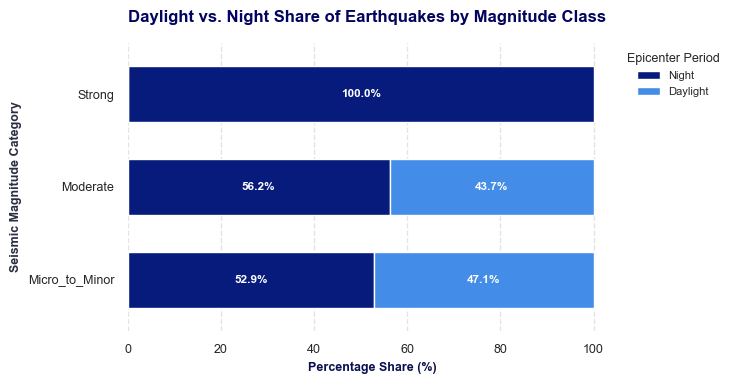

In [160]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Calculate a normalized cross-tabulation (percentages that add up to 100% per row)
crosstab_pct = pd.crosstab(
    usgs_eq_df["mag_category"], 
    usgs_eq_df["is_daylight_scientific"], 
    normalize="index"
) * 100

# Ensure clear text labels instead of True/False booleans
crosstab_pct = crosstab_pct.rename(columns={True: "Daylight", False: "Night"})

# ==============================================================================
# DESIGN
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.5, 4))

# Modern Blue and Teal Stacked Bars
crosstab_pct.plot(
    kind="barh", 
    stacked=True, 
    color=["#061B7C", "#438DE9"], 
    ax=ax, 
    width=0.6,
    edgecolor="white"
)

# Clean, Minimalist Typography & Styling
ax.set_title("Daylight vs. Night Share of Earthquakes by Magnitude Class", fontsize=12, fontweight="bold", pad=15, color="#03045E", loc="left")
ax.set_xlabel("Percentage Share (%)", fontsize=9, fontweight="semibold", color="#0B1150")
ax.set_ylabel("Seismic Magnitude Category", fontsize=9, fontweight="semibold", color="#2B2D42")
ax.tick_params(labelsize=9)

# Format X-axis grid
ax.xaxis.grid(True, linestyle="--", alpha=0.6, color="#D3D3D3")
ax.yaxis.grid(False)
sns.despine(left=True, bottom=True)

# Add explicit center-aligned data labels inside the bars
for container in ax.containers:
    labels = [f"{value:.1f}%" if value > 5 else "" for value in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8.5, fontweight="bold", color="white")

# Reposition Legend Cleanly outside or on top
ax.legend(title="Epicenter Period", title_fontsize="9", fontsize="8", loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

plt.tight_layout()
plt.show()


##### 

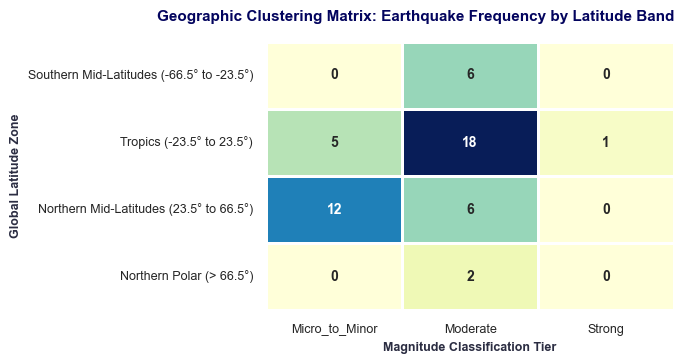

In [163]:
# 1. Create a frequency matrix counts grid
matrix_data = pd.crosstab(
    index=usgs_eq_df["latitude_zone"], 
    columns=usgs_eq_df["mag_category"]
)

# ==============================================================================
# DESIGN
# ==============================================================================
plt.figure(figsize=(7, 3.8))

# Draw the heatmap grid utilizing a beautiful, smooth modern Teal/Blue gradient
sns.heatmap(
    data=matrix_data,
    annot=True,              # Overlay the exact raw count numbers directly inside the boxes
    fmt="d",                 # Format annotations as plain decimals/integers
    cmap="YlGnBu",           # Yellow-Green-Blue sequential color profile gradient
    linewidths=2,            # Thick white borders between blocks to make them stand out cleanly
    cbar=False,               # Display the side color scale bar
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title("Geographic Clustering Matrix: Earthquake Frequency by Latitude Band", fontsize=11, fontweight="bold", pad=15, color="#03045E", loc="right")
plt.xlabel("Magnitude Classification Tier", fontsize=9, fontweight="semibold", color="#2B2D42")
plt.ylabel("Global Latitude Zone", fontsize=9, fontweight="semibold", color="#2B2D42")
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)

plt.tight_layout()
plt.show()
